# Pairs Trading — EDA

**Input:** `data/interim/prices_clean.csv` 
**Outputs:** `data/interim/prices_clean.csv`

| # | Plot |
|---|------|
| 1 | Return Distribution |
| 2 | Pairwise Correlation Distribution |
| 3 | Correlation Heatmap (Top 50) |
| 4 | Return ACF |
| + | ADF Stationarity Check |

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import acf as sm_acf, adfuller
import statsmodels.api as sm

sns.set_theme(style="whitegrid", font_scale=1.05)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook sits at project root (same level as data/, src/, outputs/)
PROJECT_ROOT = Path('.').resolve()
DATA_PATH    = PROJECT_ROOT / 'data' / 'interim' / 'prices_clean_eda_2.csv'

# ── Constants ─────────────────────────────────────────────────────────────────
MIN_TRADING_DAYS = 252
MAX_LAGS         = 20

print(f'Project root : {PROJECT_ROOT}')
print(f'Data path    : {DATA_PATH}')
print(f'Data exists  : {DATA_PATH.exists()}')

Project root : C:\Users\cathe\Documents\NUS folder\Pairs-Trading
Data path    : C:\Users\cathe\Documents\NUS folder\Pairs-Trading\data\interim\prices_clean_eda_2.csv
Data exists  : True


## Load & prep

In [2]:
# prices_clean.csv is long-format: Date, Open, High, Low, Close, Volume, Ticker
all_stocks = pd.read_csv(DATA_PATH, parse_dates=['Date'])
all_stocks = all_stocks.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Rows    : {len(all_stocks):,}')
print(f'Tickers : {all_stocks["Ticker"].nunique():,}')
print(f'Dates   : {all_stocks["Date"].min().date()} to {all_stocks["Date"].max().date()}')
all_stocks.head()

Rows    : 1,739,361
Tickers : 1,000
Dates   : 2010-01-04 to 2017-11-10


,Date,Open,High,Low,Close,Volume,Ticker
0,2010-01-04,21.245,21.350,21.014,21.128,4043084,a
1,2010-01-05,21.067,21.075,20.764,20.899,4435651,a
2,2010-01-06,20.899,20.927,20.764,20.825,3437283,a
3,2010-01-07,20.777,20.805,20.589,20.798,3279988,a
4,2010-01-08,20.683,20.825,20.520,20.791,3956596,a


In [3]:
# Compute daily return, log price, and year columns
all_stocks['Return']    = all_stocks.groupby('Ticker')['Close'].pct_change()
all_stocks['Log_Price'] = np.log(all_stocks['Close'])
all_stocks['Year']      = all_stocks['Date'].dt.year

tickers  = all_stocks['Ticker'].unique().tolist()
n_stocks = len(tickers)

# Build return pivot (dates x tickers) — reused across all plots
print('Building return pivot matrix ...')
pivot_returns = all_stocks.pivot_table(index='Date', columns='Ticker', values='Return')

# Keep only stocks with >= MIN_TRADING_DAYS non-null returns
pivot_filtered = pivot_returns.dropna(thresh=MIN_TRADING_DAYS, axis=1)
n_filtered     = pivot_filtered.shape[1]

print(f'  {n_filtered} / {n_stocks} stocks have >= {MIN_TRADING_DAYS} trading days.')


Building return pivot matrix ...
  964 / 1000 stocks have >= 252 trading days.


---
## Save outputs
Preview `returns.wide` as a wide-format dataset of returns per stocks

In [4]:
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Wide format: dates as index, tickers as columns
returns_wide    = all_stocks.pivot_table(index='Date', columns='Ticker', values='Return')
log_prices_wide = all_stocks.pivot_table(index='Date', columns='Ticker', values='Log_Price')

# returns_wide.to_parquet(PROCESSED_DIR / 'returns.parquet')
# log_prices_wide.to_parquet(PROCESSED_DIR / 'log_prices.parquet')
# print(f'returns.parquet    -> {returns_wide.shape}    saved to {PROCESSED_DIR}')
# print(f'log_prices.parquet -> {log_prices_wide.shape}  saved to {PROCESSED_DIR}')
returns_wide.head()

Ticker,a,aa,aaba,aal,aaoi,aap,aapl,abb,abbv,abc,...,yumc,yy,z,zayo,zbh,zg,zion,znga,zto,zts
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,-0.010839,-0.031126,0.007602,NaN,NaN,-0.005965,0.001751,0.006327,NaN,-0.007143,...,NaN,NaN,NaN,NaN,0.031621,NaN,0.035147,NaN,NaN,NaN
2010-01-06,-0.003541,0.051989,-0.003482,NaN,NaN,0.008735,-0.015918,0.011789,NaN,-0.009524,...,NaN,NaN,NaN,NaN,-0.000306,NaN,0.087029,NaN,NaN,NaN
2010-01-07,-0.001297,-0.021196,-0.027373,NaN,NaN,-0.000226,-0.001814,0.008285,NaN,-0.015998,...,NaN,NaN,NaN,NaN,0.022966,NaN,0.112127,NaN,NaN,NaN
2010-01-08,-0.000337,0.024596,0.000000,NaN,NaN,0.003967,0.006637,0.028439,NaN,0.010838,...,NaN,NaN,NaN,NaN,-0.021020,NaN,-0.016316,NaN,NaN,NaN
2010-01-11,0.000673,0.025357,0.002395,NaN,NaN,-0.009877,-0.008841,-0.012297,NaN,0.011144,...,NaN,NaN,NaN,NaN,0.022117,NaN,0.006077,NaN,NaN,NaN


---
## Plot 1 — Return Distribution

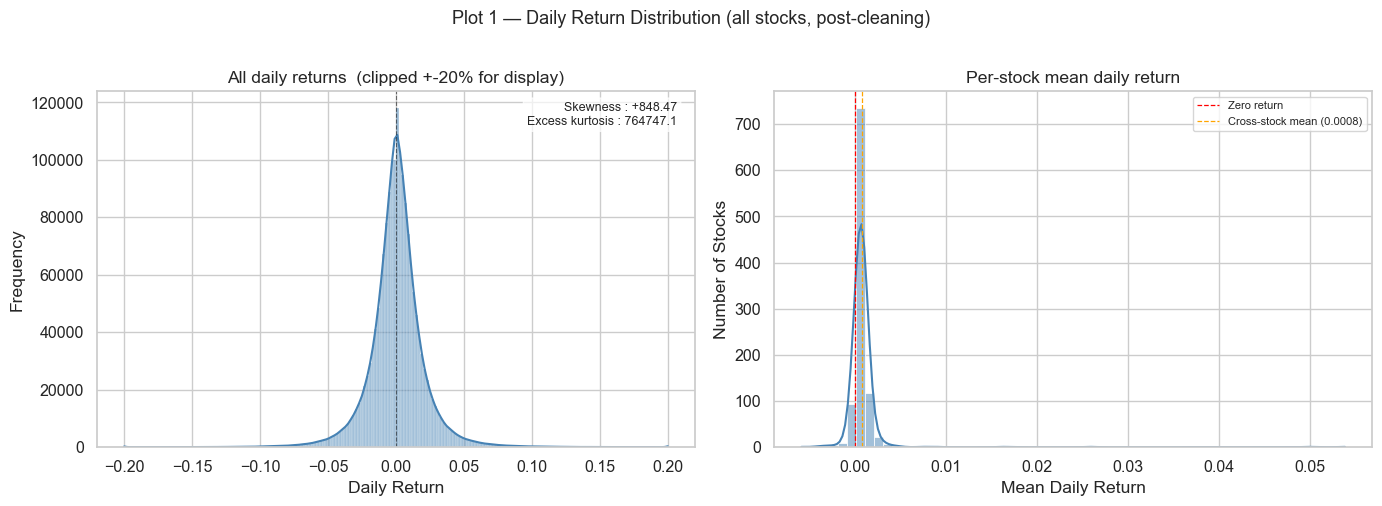

In [5]:
returns_all    = all_stocks['Return'].replace([np.inf, -np.inf], np.nan).dropna()
per_stock_mean = (
    all_stocks.groupby('Ticker')['Return']
    .mean()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 1 — Daily Return Distribution (all stocks, post-cleaning)', fontsize=13, y=1.01)

# Left: all returns clipped at +-20% so extremes don't collapse the histogram
axes[0].set_title('All daily returns  (clipped +-20% for display)')
sns.histplot(returns_all.clip(-0.2, 0.2), bins=200, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

skew = float(returns_all.skew())
kurt = float(returns_all.kurt())
axes[0].text(
    0.97, 0.97,
    f'Skewness : {skew:+.2f}\nExcess kurtosis : {kurt:.1f}',
    transform=axes[0].transAxes, fontsize=9, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
)

# Right: per-stock mean daily return
axes[1].set_title('Per-stock mean daily return')
sns.histplot(per_stock_mean, bins=60, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(0, color='red', linewidth=0.9, linestyle='--', label='Zero return')
axes[1].axvline(
    float(per_stock_mean.mean()), color='orange', linewidth=0.9, linestyle='--',
    label=f'Cross-stock mean ({per_stock_mean.mean():.4f})'
)
axes[1].set_xlabel('Mean Daily Return')
axes[1].set_ylabel('Number of Stocks')
axes[1].legend(fontsize=8)

plt.tight_layout()


---
## Plot 2 — Volatility Regimes

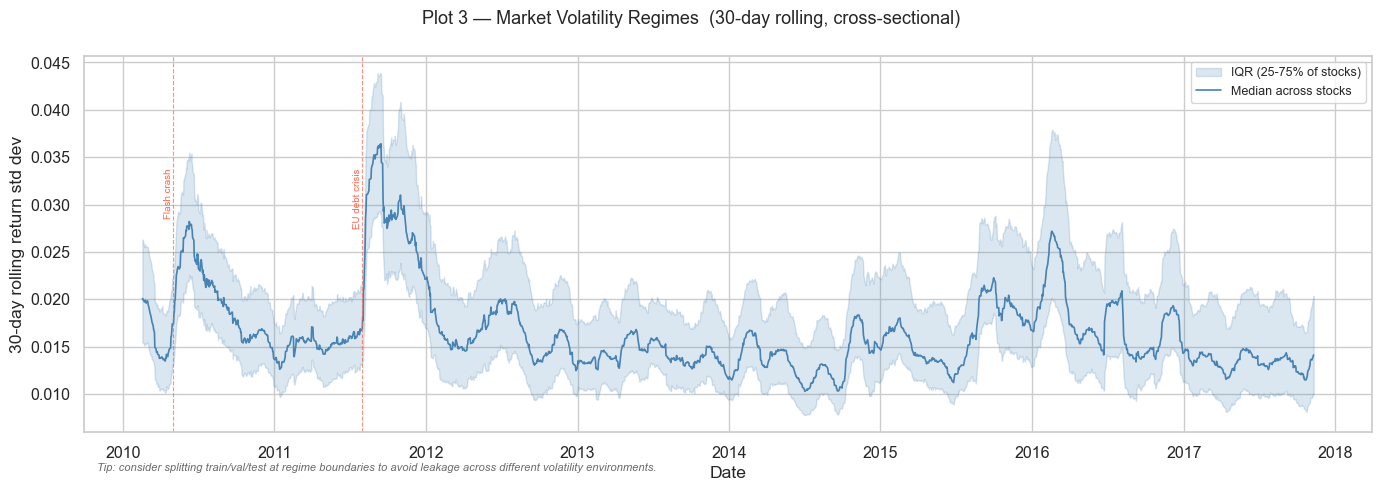

In [6]:
rolling_vol = pivot_filtered.rolling(30).std()
median_vol  = rolling_vol.median(axis=1).dropna()
p25_vol     = rolling_vol.quantile(0.25, axis=1).reindex(median_vol.index)
p75_vol     = rolling_vol.quantile(0.75, axis=1).reindex(median_vol.index)

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Plot 3 — Market Volatility Regimes  (30-day rolling, cross-sectional)', fontsize=13)

ax.fill_between(median_vol.index, p25_vol, p75_vol,
                alpha=0.2, color='steelblue', label='IQR (25-75% of stocks)')
ax.plot(median_vol.index, median_vol, color='steelblue',
        linewidth=1.2, label='Median across stocks')

regime_events = {
    '2000-03': 'Dot-com peak',
    '2002-10': 'Dot-com trough',
    '2008-09': 'GFC',
    '2010-05': 'Flash crash',
    '2011-08': 'EU debt crisis',
}
for date_str, label in regime_events.items():
    x = pd.Timestamp(date_str)
    if median_vol.index.min() <= x <= median_vol.index.max():
        ax.axvline(x, color='tomato', linewidth=0.8, linestyle='--', alpha=0.7)
        ax.text(x, float(median_vol.max()) * 0.93, label,
                color='tomato', fontsize=7, rotation=90, va='top', ha='right')

ax.set_xlabel('Date')
ax.set_ylabel('30-day rolling return std dev')
ax.legend(fontsize=9)
ax.text(
    0.01, -0.08,
    'Tip: consider splitting train/val/test at regime boundaries '
    'to avoid leakage across different volatility environments.',
    transform=ax.transAxes, fontsize=8, va='top', style='italic', color='dimgray'
)

plt.tight_layout()


---
## Plot 3 — Pairwise Correlation Distribution

Computing correlation matrix ... (may take ~30 seconds for 1000 stocks)


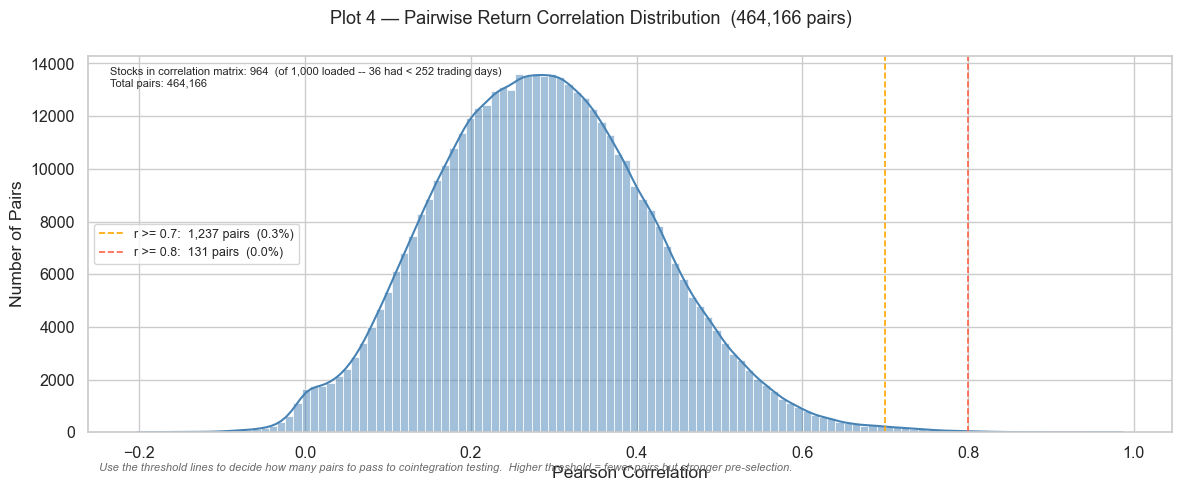

In [7]:
print('Computing correlation matrix ... (may take ~30 seconds for 1000 stocks)')
corr_matrix   = pivot_filtered.corr()
n_corr_stocks = corr_matrix.shape[0]

# Upper triangle only (excludes diagonal and duplicates)
upper_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
all_corrs  = corr_matrix.values[upper_mask]
n_pairs    = len(all_corrs)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(f'Plot 4 — Pairwise Return Correlation Distribution  ({n_pairs:,} pairs)', fontsize=13)

sns.histplot(all_corrs, bins=120, kde=True, color='steelblue', ax=ax)

for threshold, colour in [(0.7, 'orange'), (0.8, 'tomato')]:
    n_above = int((all_corrs >= threshold).sum())
    pct     = 100 * n_above / n_pairs
    ax.axvline(threshold, color=colour, linewidth=1.2, linestyle='--',
               label=f'r >= {threshold}:  {n_above:,} pairs  ({pct:.1f}%)')

ax.set_xlabel('Pearson Correlation')
ax.set_ylabel('Number of Pairs')
ax.legend(fontsize=9)
ax.text(
    0.02, 0.97,
    f'Stocks in correlation matrix: {n_corr_stocks:,}  '
    f'(of {n_stocks:,} loaded -- {n_stocks - n_corr_stocks} had < {MIN_TRADING_DAYS} trading days)\n'
    f'Total pairs: {n_pairs:,}',
    transform=ax.transAxes, fontsize=8, va='top'
)
ax.text(
    0.01, -0.08,
    'Use the threshold lines to decide how many pairs to pass to cointegration testing.  '
    'Higher threshold = fewer pairs but stronger pre-selection.',
    transform=ax.transAxes, fontsize=8, va='top', style='italic', color='dimgray'
)

plt.tight_layout()


---
## Plot 4 — Correlation Heatmap (Top 50 Stocks)

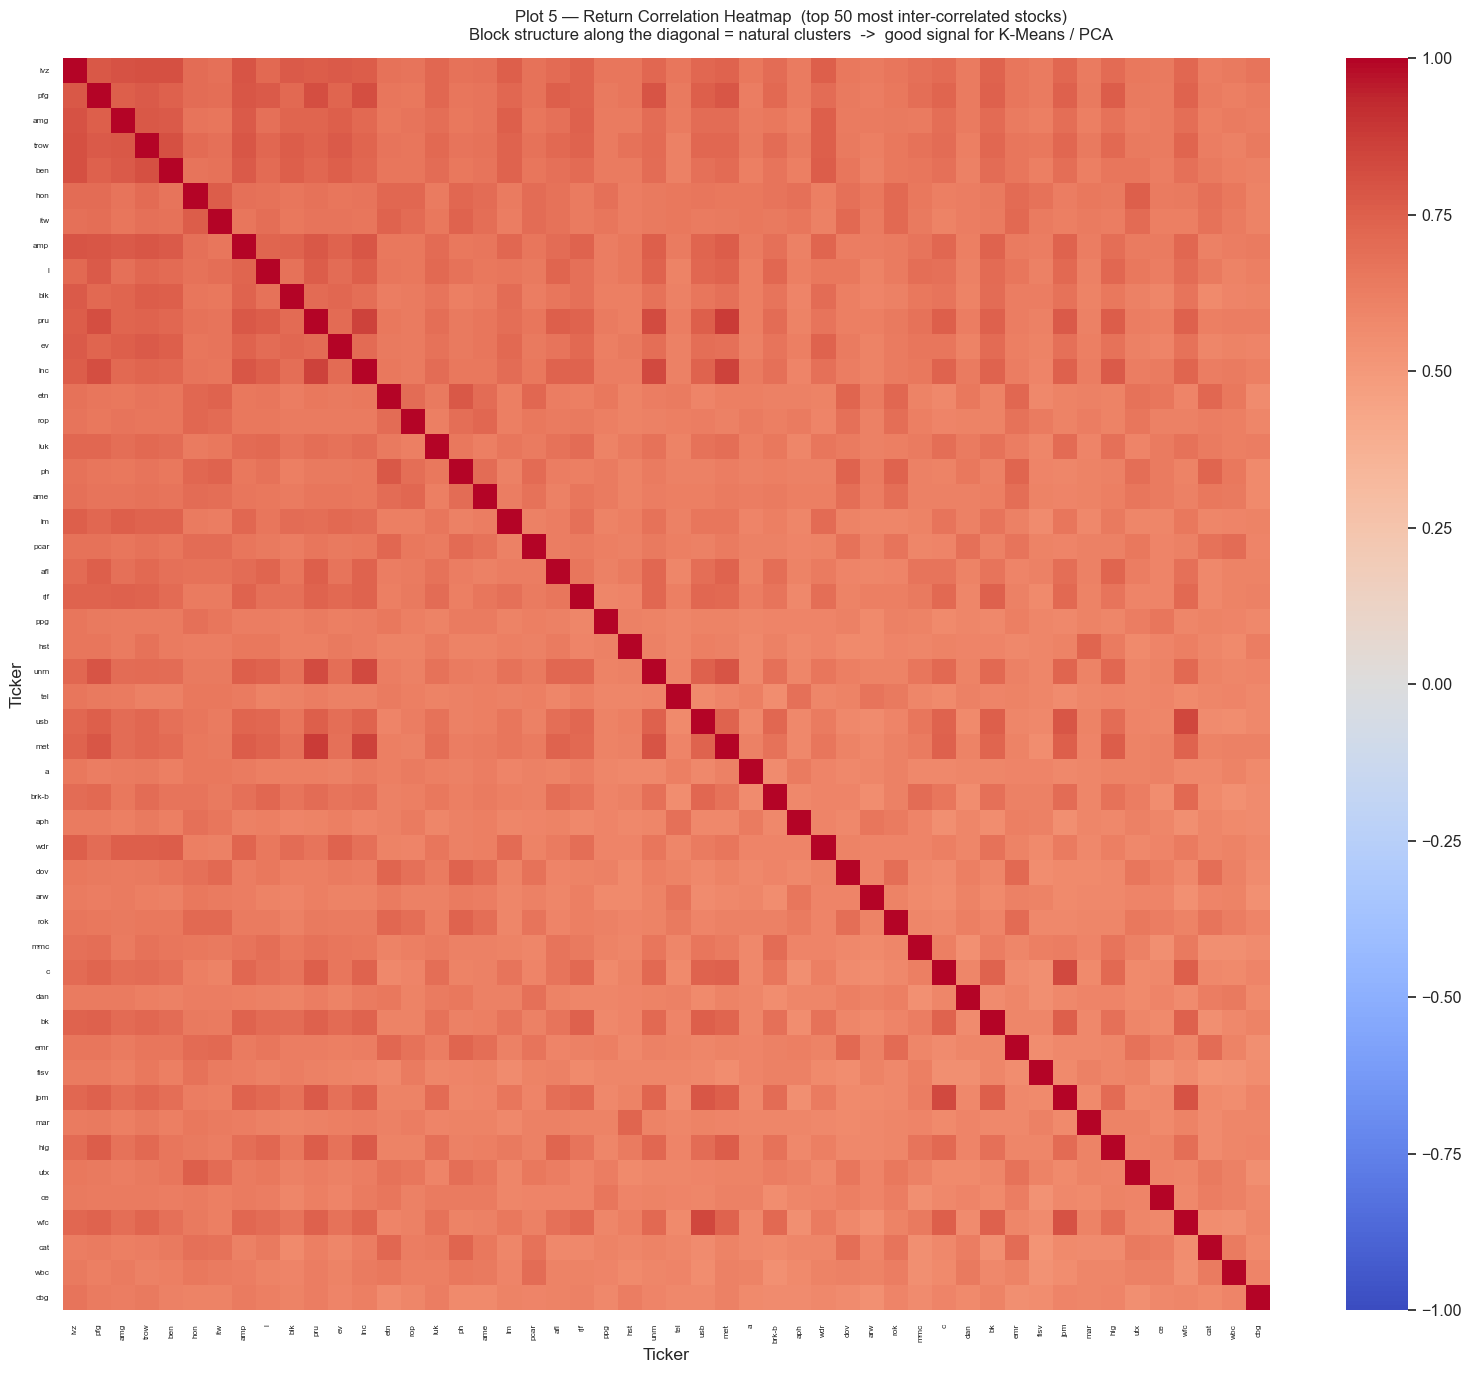

In [8]:
mean_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
top50_tickers = mean_abs_corr.head(50).index.tolist()
corr_top50    = corr_matrix.loc[top50_tickers, top50_tickers]

fig, ax = plt.subplots(figsize=(16, 14))
fig.suptitle(
    'Plot 5 — Return Correlation Heatmap  (top 50 most inter-correlated stocks)\n'
    'Block structure along the diagonal = natural clusters  ->  good signal for K-Means / PCA',
    fontsize=12
)

sns.heatmap(
    corr_top50,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=corr_top50.columns,
    yticklabels=corr_top50.columns,
    linewidths=0.0,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)

plt.tight_layout()


---
## Plot 5 — Return ACF

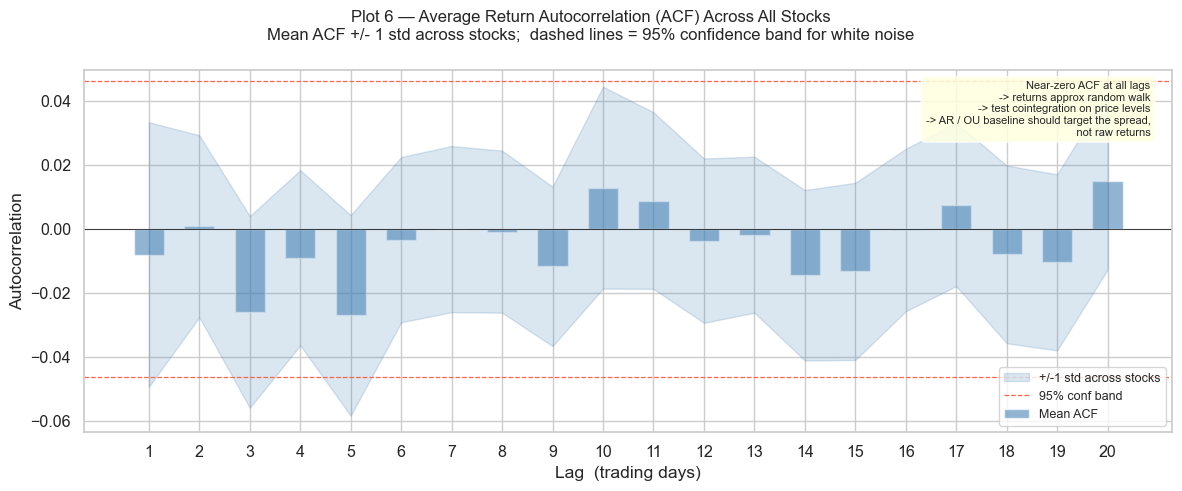

In [9]:
acf_results = []
for ticker in pivot_filtered.columns:
    series = pivot_filtered[ticker].dropna()
    if len(series) < MAX_LAGS + 10:
        continue
    try:
        vals = sm_acf(series, nlags=MAX_LAGS, fft=True)
        acf_results.append(vals)
    except Exception:
        pass

acf_matrix = np.array(acf_results)
mean_acf   = np.nanmean(acf_matrix, axis=0)
std_acf    = np.nanstd(acf_matrix,  axis=0)

avg_T  = pivot_filtered.notna().sum().mean()
conf95 = 1.96 / np.sqrt(avg_T)
lags   = np.arange(1, MAX_LAGS + 1)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(
    'Plot 6 — Average Return Autocorrelation (ACF) Across All Stocks\n'
    'Mean ACF +/- 1 std across stocks;  dashed lines = 95% confidence band for white noise',
    fontsize=12
)

ax.bar(lags, mean_acf[1:], color='steelblue', alpha=0.6, width=0.6, label='Mean ACF')
ax.fill_between(
    lags,
    mean_acf[1:] - std_acf[1:],
    mean_acf[1:] + std_acf[1:],
    alpha=0.2, color='steelblue', label='+/-1 std across stocks'
)
ax.axhline( conf95, color='tomato', linewidth=0.9, linestyle='--', label='95% conf band')
ax.axhline(-conf95, color='tomato', linewidth=0.9, linestyle='--')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('Lag  (trading days)')
ax.set_ylabel('Autocorrelation')
ax.set_xticks(lags)
ax.legend(fontsize=9)
ax.text(
    0.98, 0.97,
    'Near-zero ACF at all lags\n'
    '-> returns approx random walk\n'
    '-> test cointegration on price levels\n'
    '-> AR / OU baseline should target the spread,\n'
    '   not raw returns',
    transform=ax.transAxes, fontsize=8, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.85)
)

plt.tight_layout()


---
## ADF Stationarity Check
Confirm returns are stationary (I(0)) and prices are not (I(1)) — required assumption before cointegration testing.

In [10]:
close_pivot    = all_stocks.pivot_table(index='Date', columns='Ticker', values='Close')
sample_tickers = list(pivot_filtered.dropna(axis=1).columns[:30])

results = []
for ticker in sample_tickers:
    row = {'Ticker': ticker}

    # Price level ADF
    if ticker in close_pivot.columns:
        prices = close_pivot[ticker].dropna()
        if len(prices) > 30:
            p_val = adfuller(prices, autolag='AIC')[1]
            row['price_adf_pval']   = round(p_val, 4)
            row['price_stationary'] = p_val < 0.05

    # Return ADF
    if ticker in pivot_filtered.columns:
        rets = pivot_filtered[ticker].dropna()
        if len(rets) > 30:
            p_val = adfuller(rets, autolag='AIC')[1]
            row['return_adf_pval']   = round(p_val, 4)
            row['return_stationary'] = p_val < 0.05

    results.append(row)

adf_df = pd.DataFrame(results)
print('ADF results (sample of 30 tickers):')
display(adf_df)

price_stat  = int(adf_df.get('price_stationary',  pd.Series(dtype=bool)).sum())
return_stat = int(adf_df.get('return_stationary', pd.Series(dtype=bool)).sum())
print(f'\nPrices  stationary (p<0.05): {price_stat} / {len(adf_df)}')
print(f'Returns stationary (p<0.05): {return_stat} / {len(adf_df)}')
print('\nExpected: prices NOT stationary, returns stationary.')

ADF results (sample of 30 tickers):


,Ticker,price_adf_pval,price_stationary,return_adf_pval,return_stationary
0,a,0.9908,False,0.0,True
1,aa,0.6192,False,0.0,True
2,aaba,0.9943,False,0.0,True
3,aapl,0.9863,False,0.0,True
4,abc,0.6215,False,0.0,True
5,abev,0.1411,False,0.0,True
6,abt,0.9605,False,0.0,True
7,abx,0.7336,False,0.0,True
8,adbe,1.0000,False,0.0,True
9,adi,0.9899,False,0.0,True



Prices  stationary (p<0.05): 1 / 30
Returns stationary (p<0.05): 30 / 30

Expected: prices NOT stationary, returns stationary.


---

# Outlier Investigation

Before fixing anything, we investigate the extreme return rows to understand whether they are genuine market events or data errors.

In [11]:
# 1. Distribution of returns — see where extremes start
print('Return distribution:')
print(all_stocks['Return'].describe(percentiles=[0.001, 0.01, 0.99, 0.999]))

Return distribution:
count    1.738361e+06
mean     7.509020e-04
std      1.089031e-01
min     -9.900961e-01
0.1%    -1.234852e-01
1%      -5.915073e-02
99%      6.168724e-02
99.9%    1.336810e-01
max      9.842037e+01
Name: Return, dtype: float64


In [12]:
# 2. Which tickers have the most extreme return rows?
extreme = all_stocks[all_stocks['Return'].abs() > 0.20].copy()
print(f'Total extreme rows (|r| > 20%): {len(extreme):,}\n')
print('Top 20 tickers by extreme row count:')
print(extreme.groupby('Ticker')['Return'].count().sort_values(ascending=False).head(20))

Total extreme rows (|r| > 20%): 826

Top 20 tickers by extreme row count:
Ticker
drys    53
srpt    24
crc     17
sdrl    17
grpn    14
hznp    13
mtg     12
mtl     12
dnr     11
wtw     11
cie     11
yelp     9
soda     8
ll       8
pbyi     8
cyh      8
vrx      8
clf      7
fosl     7
fslr     7
Name: Return, dtype: int64


In [13]:
# 3. Cross-check extreme rows against volume — show return AND volume side by side
print('Top 20 most extreme rows (return vs volume):')
display(
    extreme[['Date', 'Ticker', 'Close', 'Return', 'Volume']]
    .sort_values('Return', key=abs, ascending=False)
    .head(20)
    .reset_index(drop=True)
)

Top 20 most extreme rows (return vs volume):


,Date,Ticker,Close,Return,Volume
0,2014-03-05,slg,91.079,98.420369,526697
1,2010-09-17,avb,89.284,98.237524,1398547
2,2012-03-09,eix,36.476,9.030248,2153200
3,2012-03-23,eix,36.347,8.994775,1748859
4,2012-12-24,avb,116.850,8.990595,414512
5,2013-05-31,two,11.127,8.859991,5342689
6,2013-08-06,pxd,176.270,8.810218,1398859
7,2014-07-23,pbyi,233.430,2.954430,8187074
8,2014-01-09,icpt,275.870,2.810885,6833970
9,2016-11-14,drys,313742.040,2.151555,1371


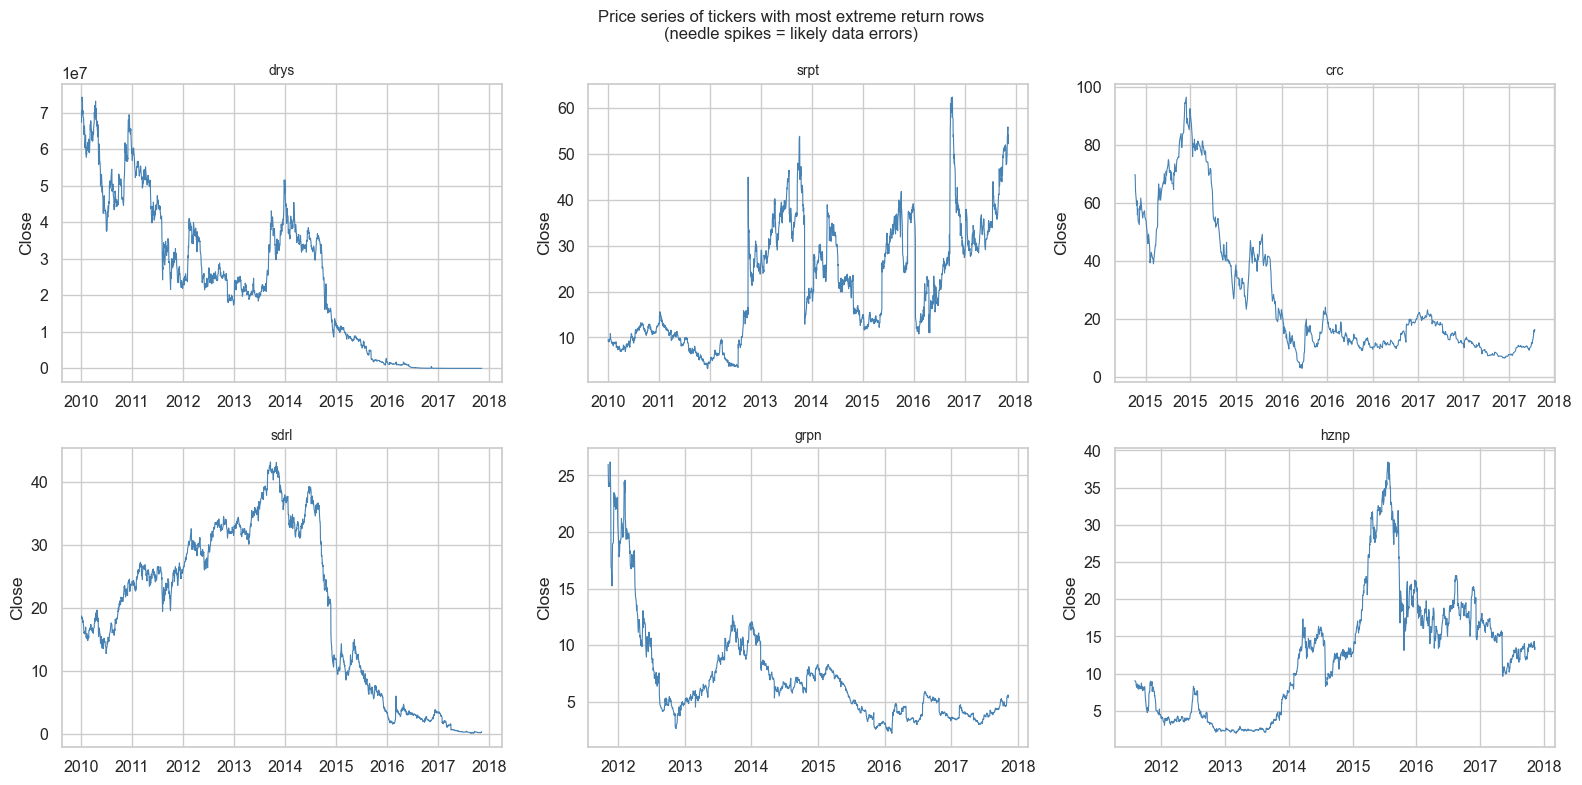

In [14]:
# 4. Plot price series for the most suspicious tickers
# A data error shows as a sudden spike then immediate return to normal
top_suspicious = (
    extreme.groupby('Ticker')['Return'].count()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Price series of tickers with most extreme return rows\n'
             '(needle spikes = likely data errors)', fontsize=12)

for ax, ticker in zip(axes.flatten(), top_suspicious):
    t_df = all_stocks[all_stocks['Ticker'] == ticker]
    ax.plot(t_df['Date'], t_df['Close'], lw=0.8, color='steelblue')
    ax.set_title(ticker, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Close')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


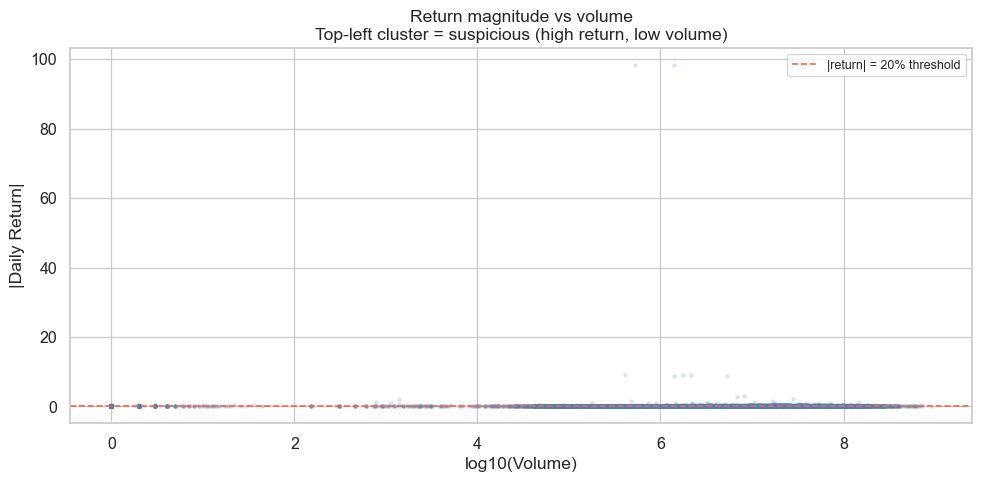

In [15]:
# 5. Return magnitude vs volume scatter
# Genuine extremes: high volume + high return (top-right)
# Data errors:      low volume  + high return (top-left) <- this is what we flag
sample = all_stocks[all_stocks['Return'].abs() > 0.05].copy()
sample['log_volume'] = np.log10(sample['Volume'].clip(lower=1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    sample['log_volume'],
    sample['Return'].abs(),
    alpha=0.15, s=5, color='steelblue'
)
ax.axhline(0.20, color='tomato', lw=1.2, linestyle='--', label='|return| = 20% threshold')
ax.set_xlabel('log10(Volume)')
ax.set_ylabel('|Daily Return|')
ax.set_title('Return magnitude vs volume\nTop-left cluster = suspicious (high return, low volume)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Summary

| Plot | Key finding | Implication |
|------|------------|-------------|
| 1. Return distribution | Leptokurtic, fat tails | Use log returns; flag-based masking for suspicious rows |
| 2. Pairwise correlation | ~0.2% pairs with r>=0.70 | Use r>=0.70 pre-filter before cointegration |
| 3. Correlation heatmap | Soft block structure (REITs, media) | PCA will find groupings; expect soft clusters |
| 4. Return ACF | Near-zero at all lags | Test cointegration on price levels, not returns |
| ADF | Returns stationary, prices not | Confirms correct input for cointegration testing |
| Outlier investigation | Suspicious rows confirmed via volume cross-check | Apply flag-based masking via handle_outliers.py |